**2장 -  머신러닝 프로젝트 처음부터 끝까지**

캘리포니아 지역 주택의 여러 특성으 ㄹ사용해 주간 가격을 예측

# 설정

In [2]:
print("머신러닝 세계에 오신 것을 환영합니다!")

머신러닝 세계에 오신 것을 환영합니다!


파이썬 3.7 또는 그 이상이 필요합니다

In [3]:
import sys

assert sys.version_info >= (3, 7)

Scikit-Learn >= 1.0.1이 필요합니다.

In [4]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

# 데이터 가져오기

## 데이터 다운로드 하기

In [5]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

## 데이터 구조 훑어 보기

In [6]:
# 처음 다섯 행 
housing.head()
# 데이터의 특성을 확인(longitude, latitude, ... , ocean_proximity)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
# 데이터에 과한 간략한 설명
housing.info()
# 전체 행의 수. 긱 특성 데이터의 type, null이 아는 개수를 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [8]:
# 카테고리 개수 확인
housing["ocean_proximity"].value_counts()
# 어떤 카테고리가 있고 각 카테고리마다 얼마나 많은 구역이 있는 확인

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [9]:
# 숫자형 특성의 요약 정보
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [10]:
IMAGES_PATH = Path() / "images" / "end_to_end_project"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution = 300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

데이터의 형태를 빠르게 검토하는 방법: 
1. 함수를 활용하여 데이터를 뜯보기 
2. 히스토그램 그려보기

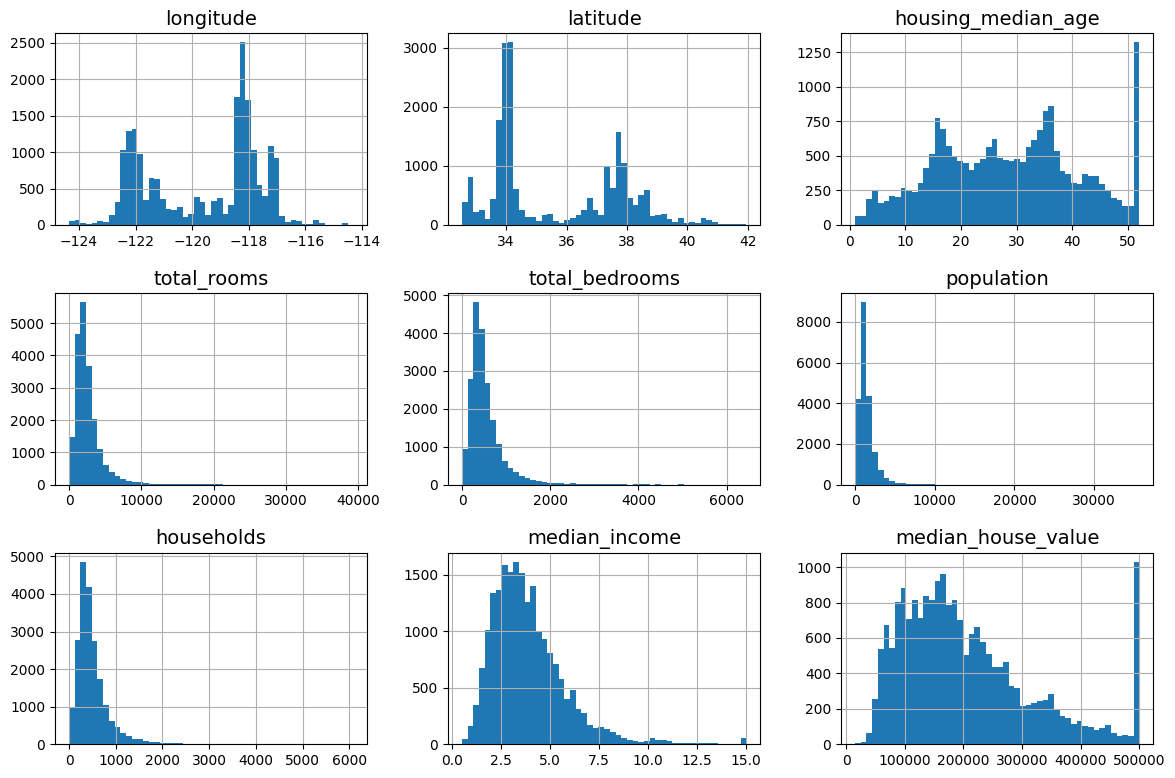

In [11]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

housing.hist(bins=50, figsize=(12, 8))
save_fig("attribute_histogram_plots")
plt.show()

히스토 그램 분석:
1. 중간 소득(median_income)특성이 uS달로로 펴현되어 있지 않음
   - 데이터 취합할 때 스케일 조정, 상한과 하한을 설정함. 

2. 중간 주택 연도(housing_median_age)와 중간 주택 가격(median_house_value)의 최소값, 최대값이 한정됨.
   - 중간 주택의 경우 타깃 레이블로 사용되기 때문에 심각한 문제가 될 수 있음.(가격이 한계값을 넘어가지 않도록 머신러닝 알고리즘이 학습될 가능성)
     - *이 시스템을 사용할 팀과 상의*

3. 특성들의 스케일이 서로 많이 다름

4. 많은 히스토그램이 오른쪽 꼬리가 더 긺.
   - 이러한 특성은 머신러닝 알고리즘에서 패턴을 찾기 어렵게 만듦
   - 나중에 이런 특성들을 좀 더 종 모양의 분포가 되도록 변형시켜야함  

## 데이터 세트 만들기

데이터 스누핑(data snooping) 편향이 일어나지 않도록 학습,테스트용으로 데이터를 8:2 비율로 분리

In [12]:
import numpy as np

# 데이터 섞은 후 split
def shuffle_and_split_data(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_sets_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_sets_size]
    train_indices = shuffled_indices[test_sets_size:]
    return data.iloc[train_indices], data.iloc[test_indices]
    

In [13]:
train_set, test_set = shuffle_and_split_data(housing, 0.2)
print(f"train set : {len(train_set)}")
print(f"test set  : {len(test_set)}")

train set : 16512
test set  : 4128


노트북 실행 결과를 일정하기 유지하게 위해 랜덤 시즈 고정

In [14]:
np.random.seed(42)

데이터를 train/test set으로 나누되, 
ID 기준으로 항상 같은 데이터가 test set에 들어가게 만드는 코드

=> 데이터가 추가되어도 기존 데이터의 train/test 소속이 바뀌지 않음

In [15]:
from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

해당 데이터셋에 존재하지 않는식별자 컬럼을 index를 생성하여 사용

In [16]:
housing_with_id = housing.reset_index() # 'index' 열 추가
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

행의 인덱스를 고유 식별자로 사용할 때 
- 새 데이터는 데이터셋의 끝에 추가되어야 하고
- 어떤 행도 삭제되선 안됨

그렇기 때문에 index를 안전하게 변환해줄 필요가 있음

In [17]:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")

데이터를 서브셋(subset)으로 나누기

In [18]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

결측치 개수 확인

In [19]:
test_set["total_bedrooms"].isnull().sum()

44

인구의 여성 비율이 51.1%일 때 1,000명으로 구성된 랜덤 샘플에서 여성이 48.5% 보다 작거나 53.3% 보다 많을 확률을 계산하려면 [이항 분포](https://en.wikipedia.org/wiki/Binomial_distribution)를 사용합니다. 이항 분포의 `cdf()` 메서드는 여성의 수가 주어진 값보다 작거나 같을 확률을 반환합니다.

In [20]:
# 추가 코드 - 나쁜 샘플을 어들 활률 10.7%를 게산하는 방법

from scipy.stats import binom

sample_size = 1000
ratio_female = 0.511
proba_too_small = binom(sample_size, ratio_female).cdf(485 - 1)
proba_too_large = 1- binom(sample_size, ratio_female).cdf(535)
print(proba_too_small + proba_too_large)

0.10736798530929942


수학 대신 시물레이션을 해도 거의 동일한 결과를 얻을수 있음

In [21]:
# 추가 코드 – 나쁜 샘플을 얻을 확률을 시물레이션으로 계산 하는 방법

np.random.seed(42)

samples = (np.random.rand(100_000, sample_size) < ratio_female).sum(axis=1)
((samples < 485) | (samples > 535)).mean()

0.1071

In [22]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

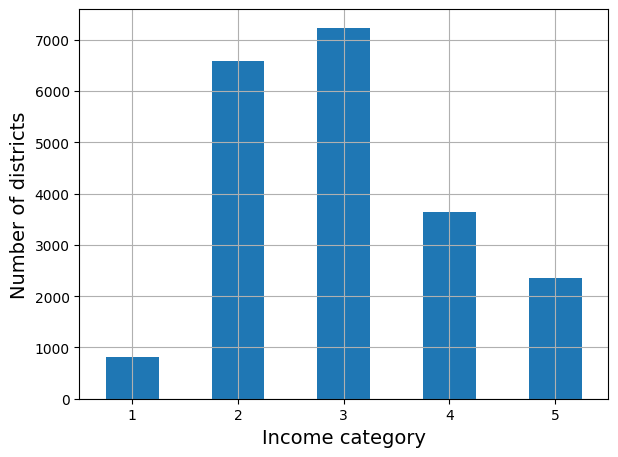

In [23]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
save_fig("housing_income_cat_bar_plot(extra)")  # extra code
plt.show()

In [24]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    strat_train_set_n = housing.iloc[train_index]
    strat_test_set_n = housing.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [25]:
strat_train_set, strat_test_set = strat_splits[0]

하나의 계층적 분할을 얻기 위해서는 이 방법이 훨씬 간단함:

In [26]:
strat_train_set, strat_test_set = train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

In [27]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [28]:
# 추가 코드 – 그림 2–10를 생성

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
1,3.98,4.00,4.24,0.36,6.45
2,31.88,31.88,30.74,-0.02,-3.59
3,35.06,35.05,34.52,-0.01,-1.53
4,17.63,17.64,18.41,0.03,4.42
5,11.44,11.43,12.09,-0.08,5.63


In [29]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

# 데이터 이해를 위한 탐색과 시각화

In [30]:
housing = strat_train_set.copy() # train set 복사

## 지리적 데이터 시각화

해당 데이터셋에는 지리정보(위도,경도)가 퐘되어 있어 모든 구역의 산점도를 시각화해 보면 좋음

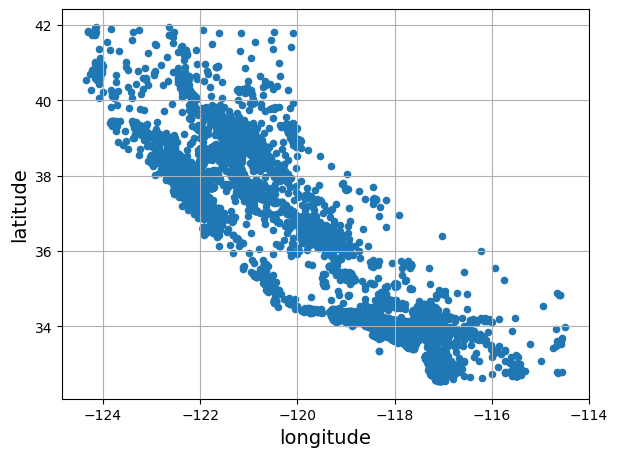

In [31]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)
save_fig("bad_visualization_plot")
plt.show()

해당 산점도에는 캘리포니아 지역을 잘 나타내지만 특별한 패턴을 찾기는 힘듦.

-> alpha 옵션을 0.2로 주어 밀집된 지역을 표현

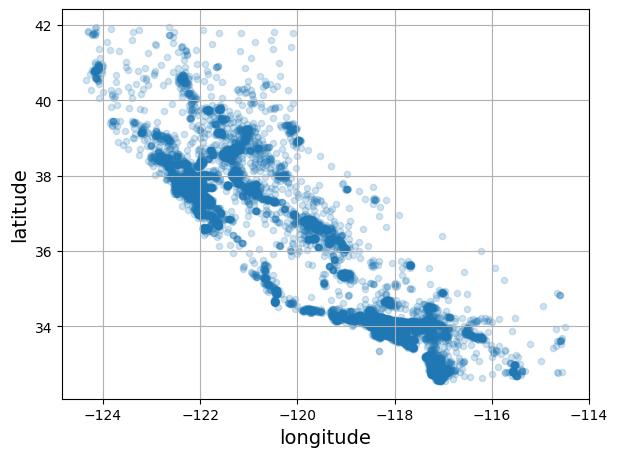

In [32]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
save_fig("better_visualization_plot")
plt.show()

산점도 분석 : 
1. 베이 에어리어(Bay Area)와 로스엔젤레스(Los Angeles) 근처, 샌디에이고(Sandiego)같이 밀집된 지역이 눈에 잘 띔.
2. 센트럴 밸리(Central Valley)에 밀집되 지역이 긴 띠를 이루고 있음

우리는 이미지를 잘 인식하지만, 컴퓨터가 좀 더 두드러진 패턴을 보기 위해서는 다양한 매개변수를 조절해 봐야함

그 첫번째로 주택 가격 시각화(파란색에 가까울소록 낮은 가격, 빨간색에 가까울수록 높은 가격)

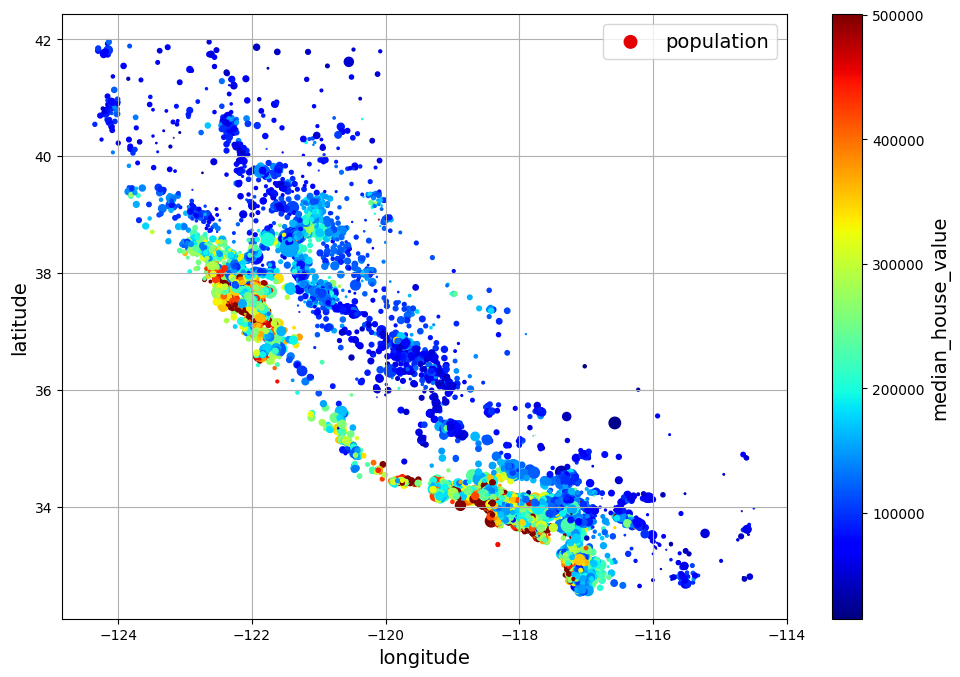

In [33]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, figsize=(10, 7))
save_fig("housing_prices_scatterplot")
plt.show()

산점도 분석 : 
1. 주택 가격은 지역(바다와 인접한 곳) 및 인구 밀도와 관련성이 높음
   - 군집 알고리즘을 사용해 주요 군집을 찾고 군집의 중심까지의 거리를 재는 특성을 추가할 수 있어짐

다음 셀은 이 장에 있는 첫 번째 그림을 생성함. 
이 그림은 배경에 캘리포니아 이미지를 넣고, 레이블 이름을 바꾸고, 그리드를 삭제하여 이전 그림을 더 멋있게 만든 것

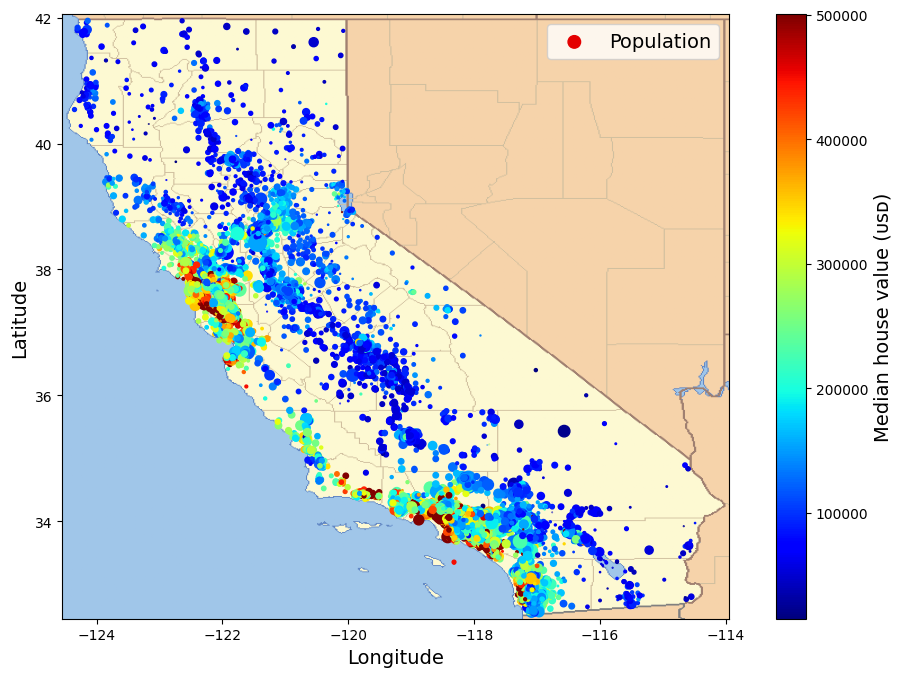

In [34]:
#  캘리포니아 이미지를 다운로드
filename = "california.png"
if not (IMAGES_PATH / filename).is_file():
    homl3_root = "https://github.com/ageron/handson-ml3/raw/main/"
    url = homl3_root + "images/end_to_end_project/" + filename
    print("Downloading", filename)
    urllib.request.urlretrieve(url, IMAGES_PATH / filename)

housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed.plot(
             kind="scatter", x="Longitude", y="Latitude",
             s=housing_renamed["Population"] / 100, label="Population",
             c="Median house value (ᴜsᴅ)", cmap="jet", colorbar=True,
             legend=True, figsize=(10, 7))

california_img = plt.imread(IMAGES_PATH / filename)
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis)

save_fig("california_housing_prices_plot")
plt.show()

## 상관관계 조사

데이터셋이 너무 크지 않으므로 모든 특성 간의 **표준 상관계수(Standard correlation coefficient)** 를 corr()메서드로 계산할 수 있음.

( **피어슨(Pearson)** 의 r이라고도 부름)

In [35]:
# 판다스 1.5버전부터 수치형 데이터만 포함하는지 여부를 결정하는 `numeric_only` 매개변수가 추가되었습니다.
# 이 매개변수의 기본값은 `True`입니다.
# 판다스 2.0버전에서 기본값이 `False`로 바뀌므로 명시적으로 `numeric_only=True`로 지정합니다.
corr_matrix = housing.corr(numeric_only=True)

중간 주택 가격과 다른 특성 사이의 상관관계 크기 확인

In [36]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

상관관계의 범위는 -1부터 1까지임. 
- 1에 가까우면 강항 양의 상관관계를 가진다는 뜻
- -1에 가까우면 강한 음의 상관관계를 가진다는 뜻
- 0에 가가우면 선형적인 상관관계가 없다는 뜻

특성사이의 상관관계를 확인하는 다른 방법은 scatter_matrix함수를 사용하여 숫자형 특성 간 산점도를 그리는 것.

여기서 숫자형 특성이 9개이므로 $9^2=81$ 개의 그래프가 그려집니다. 저는 간단하게 중간 주택 가격과 상관관계가 높아보이는특성만 몇개만 그려보겠음

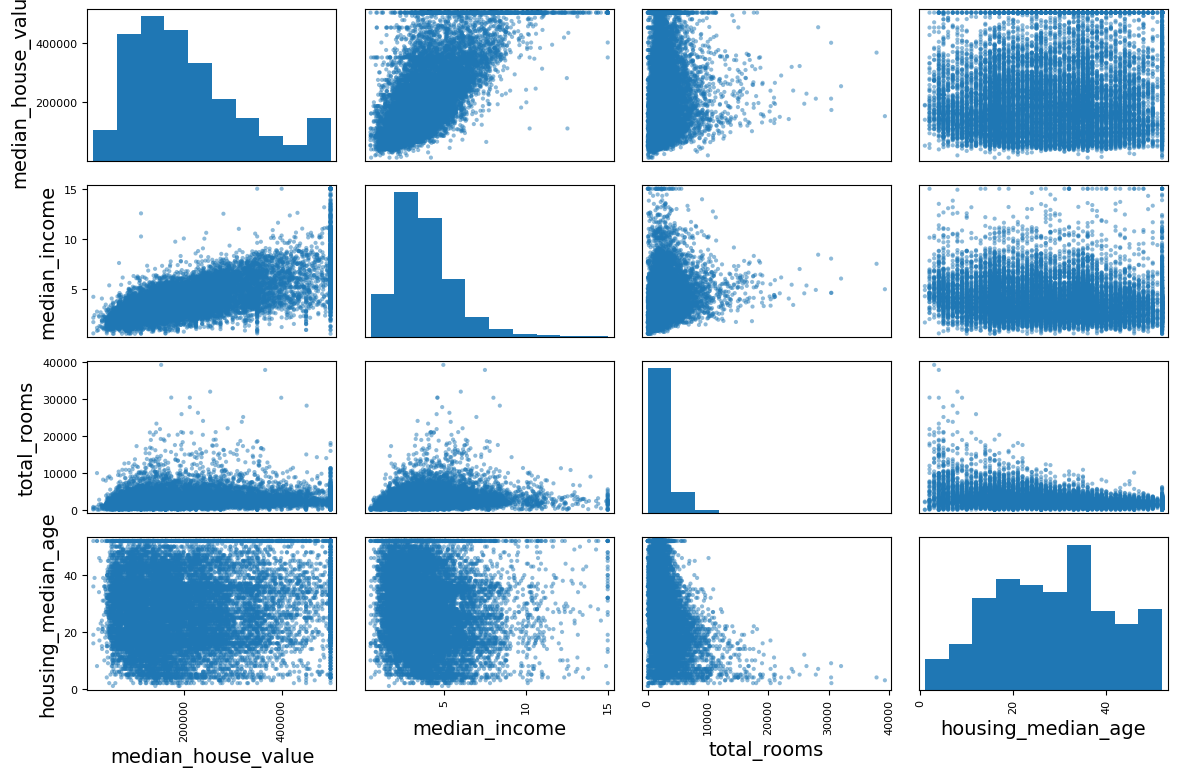

In [37]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
save_fig("scatter_matrix_plot")  # 추가 코드
plt.show()

산점도 행렬을 보니 중간 주택 가격(median_house_value)을 예측하는 데 중간 소득(median_income)이 가장 유용해 보임.

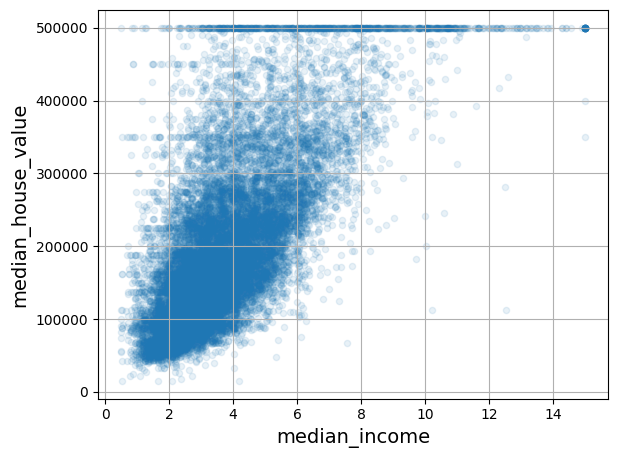

In [38]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
save_fig("income_vs_house_value_scatterplot")  # e추가 코드
plt.show()

그래프 분석 : 
1. 상관관계가 아주 강함
   - 왼쪽으로 향하는 경향을 볼 수 있으며 포인트들이 너무 많이 펴져 있지 않음.

2. 앞서 본 가격 한계값이 $500,000에서 수평선으로 잘 보임.

3. 이 그래프는 직선에 가가운 형태가 더 나타남($450,000 , $350,000 , $280,000)
   - 이런 경우 알고리즘이 데이터에서 이런 이상한 형태를 학습하지 않도록 해당 구역을 제거 

## 특성 조합으로 실험

머신러닝 알고리즘에 주입하기 전에 정제해야 할 조금 이상한 데이터를 확인함.

특정 사이에서 흥미로운 상관관계를 발견함.

머신러능 알고리즘용 데이터를준비하기 전에 마지막으로 할 수 있는 일은 특성을 여러 가지로 조합해보는 것.

In [39]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

상관관계 행렬을 다시 확인

In [40]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

분석 : 
1. 새로운 bedrooms_ratio 특성은 전체 방 개수나 침실 개수보다 중간 주택 가격과의 상관관계가 훨씬 높음.
   - 확실히 침실/방의 비율이 낮은 집은 더 비싼 경향이 있음
   - 가구당 방 개수도 구역 내 전체 방개수보다 더 유용함 -> 당연히 큰 집이 더 비쌈


하지만 이 탐색은 완벽하지 않음. 

빠르게 시작하여 인사이트를 얻는 것이 합리적인 첫 번째 프로토타입을 만드는데 도움이 됨.
하지만 이는 반복과정임. 프로토타입을 만들고 실행한 후 그 결과를 분석하여 더 많은 인사이트를 얻고 다시 이 탐색 단계로 돌아게 됨

# 머신 러닝 알고리즘을 위한 데이터 준비

원본 훈련 세트로 복원하고 타깃을 분리해야함.
(`strat_train_set/drop()`은 지정한 열을 제외한 `strat_train_set`은 복사본을 만듦. `strat_train_set` 자체를 수정하지 않음) 

In [41]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

## 데이터 정제

대부분의 머신러닝 알고리즘은 누락된 특성을 다루지 못함. 이를 처리할 수 있는 함수를 작성해야함.

```python
housing.dropna(subset=["total_bedrooms"], inplace = True) # 해당 구역 제거

housing.drop("total_bedrooms", axis=, inplace=True) # 전체 특성을 삭제

median = housing["total_bedrooms"].median() #누락된 값을 다른 값으로 치환
housing["total_bedrooms"].fillna(median, inplace=True)
```

각각의 방법에 대해 `housing`을 오염시키지 않기 위해 복사본을 만들어사용.
각 방법의 출력으 확인하지만 NaN을 담고 있는 행은 필터링 함

In [42]:
null_rows_idx = housing.isnull().any(axis=1)
housing.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN


In [43]:
housing_option1 = housing.copy()

housing_option1.dropna(subset=["total_bedrooms"], inplace=True) # 해당 구역 제거

housing_option1.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


In [44]:
housing_option2 = housing.copy()

housing_option2.drop("total_bedrooms", axis=1, inplace=True) # 전체 특성을 삭제

housing_option2.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,375.0,183.0,9.8020,<1H OCEAN


In [45]:
housing_option3 = housing.copy()

median = housing["total_bedrooms"].median()
housing_option3["total_bedrooms"].fillna(median, inplace=True) # 누락된 값을 다른 값으로 치환

housing_option3.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020,<1H OCEAN


3가지 방법 모두 데이터를 최대한 유지하므로 이를 주로 선택.

`SimpleImputer` 클래스를 활용하여 편리하게 동작 수행 (이 클래스는 각 특성의 중간값을 저장하고 있어서 유용함)

훈련 세트뿐만 아니라 검증 세트와 테스트 세트 그리고 모델에게 주입될 새로운 데이터에 있는 누락값을 대체할 수 있음.
이를 사용하기 위해 먼저 누락된 값을 특성의 중간값으로 대체하도록 지정하여 `SimpleImputer`지정

In [46]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

`"median"` 전략을 사용하기 위해 수치 특성을 분리(`ocean_proximity` 같은 텍스트 특성에서는 계산할 수 없음):

In [47]:
housing_num = housing.select_dtypes(include=[np.number])

이제 imputer 객체에`fit()` 메서드르 사용해 훈련 데이터에 적용할 수 있음:

In [48]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [49]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

각 특성의 중간 값을 수동으로 계산한 것과 같은지 비교

In [50]:
housing_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

훈련세트를 변환

In [51]:
X = imputer.transform(housing_num)

In [52]:
imputer.feature_names_in_

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

사이킷런 변환기는 판다스 데이터프레임이 입력되어도 numpy배열을 출력함

따라서 inputer.transform(housing_num)의 출력은 numpy배열임.
X에는 열이름도 없고, 인덱스도 없음 -> X를 데이터프레임으로 감싸서 housing_num으로부터 열 이름과 인덱스를 복원해야함

In [53]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index) 

In [54]:
housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020


In [55]:
imputer.strategy

'median'

In [56]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

In [57]:
housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020


## 텍스트와 범주형 특성 다루기


이전까지는 숫치형 특성만 다뤘지만 이제는 텍스트 특성을 볼 차례

데이터 셋은 `ocean_proximity`만 있음.

In [58]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


가능한 값을 제한된 개수로 나열한 것. 각 값은 카테고리를 나타냄.
-> 범주형 특성


머신러닝을 주로 숫자를 다루기 때문에 카테고리를 숫자로 변환(OrdinalEncoder 클래스)

In [59]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoder = ordinal_encoder.fit_transform(housing_cat)

housing_cat_encoder에 인코딩된 몇 개의 값을 확인:

In [60]:
housing_cat_encoder[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [61]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

문제점 : 무신러닝 알고리즘이 가까이 있는 두 값을 떨어져 있는 두 값보다 더 비슷하다고 생각한다느 점. (일부는 괜찮음 -> bad, average, good ... 등 순서가 있는경우)

해결법 -> **원-핫 인코딩(onehot encoding)** : 카테고리가 '<1H OCEAN'일 떄 한 특성이 1이고(그 외 특성은 0), 카테고리가 'INLAND'일 때 다른 한 특서이 1이되는(역시 그 외에는 0)이 되는 방식.

이따금 새로운 특성을 **더미(dummy)** 특성리고도 부름

범주의 값을 원-핫 벡터로 바꾸기 위해 `OneHotEncoder` 클래스 사용

In [62]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

기본적으로 OneHotEncoder의 출력은 넘파이 배열이 아니라서 사이파이 **희소 행렬**임

In [63]:
housing_cat_1hot

<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

대부분 희소 행렬을 보통 2D 배열처럼 사용할 수 있지만 (밀집된) numpy 배열로 바꾸려면 `toarray()`메서드를 호출해야함

In [64]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

또는 OneHotEncoder를 만들때 `sparse=False`(또는 `sparse_output=False`) 메서드가 일반적인 넘파일 배여을 반환할수 있게해줌

In [65]:
# 사이킷런 1.2버전에서 `sparse_output` 매개변수가 추가되었고 `sparse` 매개변수는 1.4버전에서 삭제됨.
# 이에 대한 경고를 피하려면 `sparse_output`을 사용헤애힘
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

In [66]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [67]:
df_test_unknown = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
pd.get_dummies(df_test_unknown)

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,True,False
1,False,True


handle_unkown 매개변수를 "ignore"로 지정하여 알 수 없는 카테고리르 그냥  0 으로 나타낼 수 있음:

In [68]:
cat_encoder.handle_unknown = "ignore"
cat_encoder.transform(df_test_unknown)

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

데이터프레임을 사용한 사이킷런 추정기를 훈련할때는 추정기 열 이름을 `feature_names_in_`속성에 저장함

그 다음 사이킷런은 이 추정 김에 입력된 모든 데이터프레임이 동일한 열 이름을 가지고 있는지 확인함.

In [69]:
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [70]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [71]:
df_output = pd.DataFrame(cat_encoder.transform(df_test_unknown),
                         columns=cat_encoder.get_feature_names_out(),
                         index=df_test_unknown.index)

In [72]:
df_output

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0


## 특성 스케일링

**특성 스케일링(feature scaling)** 은 데이터 적용할 중요한 변환 중 하나입니다.

몇가지를 제외하고 머신러닝 알고리즘은 입력된 숫자 특성들의 스케일이 많이 다르면 제대로 작동하지 않음.

일반적으로 모든 특성의 범위를 같게 만들어주는 방법으로 **min-max 스케일링**과 **표준화(standardization)** 가 널리 사용됨

min-max 스케일링: 
- 가장 간단한 방법
- **정규화(normalization)** 이라고 불림
- 각 특성에대허서 0 ~ 1 범위에 들도록값을 이동하고 스케일을 조정함.
- 데이터에서 최소값을 뺀 후 최댓값과 최소값의 차이로 둠
- `MinMaxScaler` 변환기를 제공함.

In [73]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1 ,1))  # 0 ~ 1
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

표준화(standardization):
- min-max 스케일링과 다름
- 평균을 먼저 뺀 후(표준화 하면 항상 평균이 0), 
    
    표준 편차로 나눔(표준화된 값의 표준 편차는 1)
- min-max 스케일링과 달리 특정 범위로 제한을 두지 않음 -> 이상치에 영향을 덜 받음
- `StandardScaler` 변환기를 제공함.

In [74]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

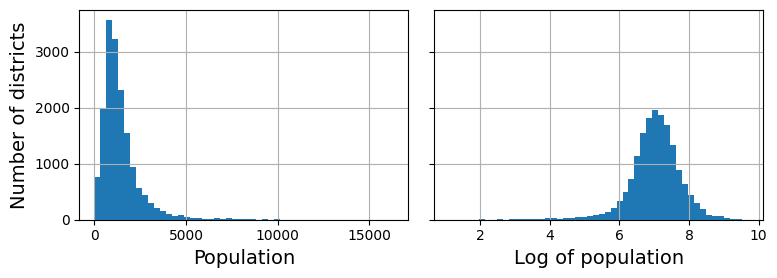

In [75]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axs[0], bins=50)
housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
save_fig("long_tail_plot")
plt.show()

각 값을 백분위수로 변환(균등 분포를 얻는다는 것을 확인)

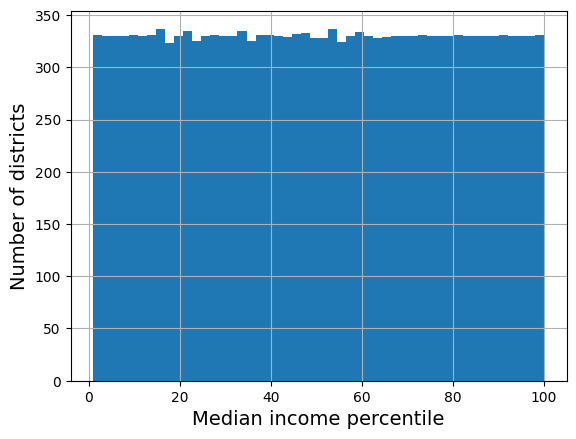

In [76]:
percentiles = [np.percentile(housing["median_income"], p)
               for p in range(1, 100)]
flattened_median_income = pd.cut(housing["median_income"],
                                 bins=[-np.inf] + percentiles + [np.inf],
                                 labels=range(1, 100 + 1))
flattened_median_income.hist(bins=50)
plt.xlabel("Median income percentile")
plt.ylabel("Number of districts")
plt.show()
# Note: 1 백분위수 아래의 소득은 1로 레이블되고 99 백분위수 이상의 값은 100으로 레이블됨.
# 이 때문에 아래 분포의 범위가 1에서부터 100까지임 (0에서부터 100까지가 아님).

멀티모달 분포룰 변환하는 방법: 중간 주택 연도와 특정 모드 사이의 유사돌를 나타내는 특성을 추가하는 것. 일반적으로 유사도 측정은 입력값과 고정 포인트 사이의 거리에만 의존하는 **방사 기저 함수(radial basis function, RBF)** 를 사용함.

In [77]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

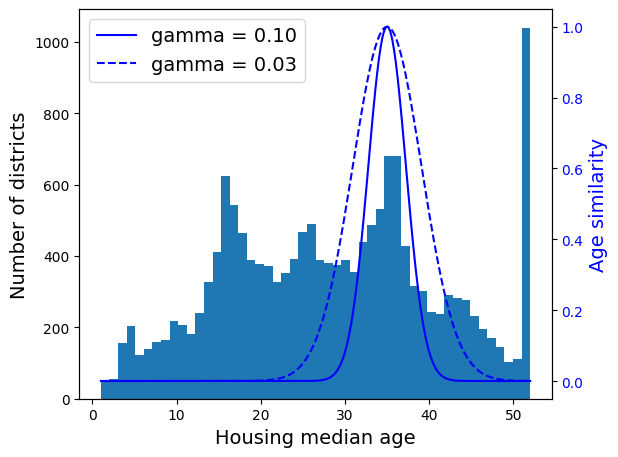

In [78]:
ages = np.linspace(housing["housing_median_age"].min(),
                   housing["housing_median_age"].max(),
                   500).reshape(-1, 1)
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(housing["housing_median_age"], bins=50)

ax2 = ax1.twinx()
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("Age similarity", color=color)

plt.legend(loc="upper left")
save_fig("age_similarity_plot")
plt.show()

지금까지 입력 특성만 보았지만 타깃값도 변환이 필요할 수 있음.
예) 만약 타깃 분포의 꼬리가 두껍다면 타깃을 로그값으로 바꿀수 있음
-> 이렇게 하면 회귀 모델이 중간 주택 가격 자체가 아니라 중간 주택 가격의 로그를 예측하게 됨. 중간 주택 가격을 얻고 싶다면 모델 예측에 지수함수를 적용해야함.

-> `inverse_transform()` 메서드로 가능

In [79]:
from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
some_new_data = housing[["median_income"]].iloc[:5]  # 새로운 데이터라고 가정

scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)

In [80]:
predictions

array([[131997.15275877],
       [299359.35844434],
       [146023.37185694],
       [138840.33653057],
       [192016.61557639]])

더 간단한 방법 -> `TransformedTargetRegressor` 사용

이 클래스의 객체를 생성한 다음 회귀 모델과 레이블 변환기를 전달하고 스케일링되지 않은 원본 모델을 사용해 훈련 세트로 훈련함.

In [81]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(),
                                   transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)
predictions = model.predict(some_new_data)

In [82]:
predictions

array([131997.15275877, 299359.35844434, 146023.37185694, 138840.33653057,
       192016.61557639])

## 사용자 정의 변환기

사이킷런이 유용한 변환기를 많이 제공하지만 사용자 정의 변환, 정제 연산, 특성 결합과 같은 작업을 위해 자신만의 변환기를 작성할 필요가 있음


간단한 변환기 작성

-> 특성 분포의 꼬리가 두꺼울 때는(특성이 양소이고 두꺼운 꼬리가 오른쪽이라고 가정) 로그값으로 바꾸는 것이 좋은 경우가 있음. 이때의 로그 변환기

In [83]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])

사용자 정의 변환 함순느 추가적인 인수로 하이퍼파라미터를 받을 수 있음:

(예를 들어 가우스 RBF 유사도를 계산하는 변환기를 아래와 같이 만들 수 있음)

In [84]:
rbf_transformer = FunctionTransformer(rbf_kernel, kw_args=dict(Y=[[35.]], gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])

In [85]:
age_simil_35

array([[2.81118530e-13],
       [8.20849986e-02],
       [6.70320046e-01],
       ...,
       [9.55316054e-22],
       [6.70320046e-01],
       [3.03539138e-04]])

두 개의 특서을 가진배열을 전다하면 유사도를 측저앟기 위해 2D 거리(유클리드 거리)를 계산해야함.

아래의 코드는 각 구여고가 샌프란시스코 사이의 지리적 유사도를 측정하는 특성을 추가한느 코드

In [86]:
sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel,
                                     kw_args=dict(Y=[sf_coords], gamma=0.1))
sf_simil = sf_transformer.transform(housing[["latitude", "longitude"]])

In [87]:
sf_simil

array([[0.999927  ],
       [0.05258419],
       [0.94864161],
       ...,
       [0.00388525],
       [0.05038518],
       [0.99868067]])

사용자 특성 변환기는 특성을 합칠 때도 유용함

(예를 들어 다음은 첫 번째 입력 특성과 두번째 특서 사이의 비융을 계산하는 FunctionTransformer)

In [88]:
ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])
ratio_transformer.transform(np.array([[1., 2.], [3., 4.]]))

array([[0.5 ],
       [0.75]])

사이킷런에서는 직접 만든 전처리 클래스도 `fit()`, `transform()` 메서드를 갖추면 파이프라인에서 사용할 수 있다.  

아래의 `StandardScalerClone`은 사이킷런의 `StandardScaler`와 비슷하게 각 특성의 평균과 표준편차를 학습한 뒤, 데이터를 표준화하는 사용자 정의 변환기이다.

In [89]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __int__(self, with_mean=True): # *args, **kwargs를 사용하지 않음
        self.with_mean = with_mean
        
    def fit(self, X, y=None): # 사용하진 않아도 y는 있어야함
        X = check_array(X) # X가 부동수수점 배열인지 확인
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1] # (훈련으로) 학습된 속성이 있는지 확인
        return self # 항상 self를 반환해야함
    
    def transform(self, X):
        check_is_fitted(self) # (훈련으로) 학습된 속성이 있는지 확인
        X = check_array(X)
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_

주의 사항:
1. sklearn.utils.validation 패키지에는 입력을 검증하기 위해 사용할 수 있는 함수가 여러 있음.
2. 사이키런 파이프라인은 X와 y 두 개의 매개변수를 가진 매서드가 필요함. 그리서 y를 사용하지 않아도 작성은 해야함
3. 모든 사이킷런 추정기는 fit() 매서드 안에서 n_features_in_을 설정하고 transform()이나 predict() 메서드에 전달된 데이터의 특서 개수가 동일한지 확인해야함
4. fit() 메서드는 self를 반환해야함.

5. 이 구현은 100% 완벽하지 않음. 모든 추정ㄱ는 데이터프레임이 전달되 때 fit() 메서드 안에서 feature_names_in_을 설정해야함. 또한 모든 변환기는 get_features_names_out() 메서드와 역변환을 위한 inverse_transform()메서드를 제공해야함

하나의 사용자 변환기가 구현 안에서 다른 추정기를 사용할 수 있음

아래의 코드는 fit() 메서드안에서 훈련 데이터에 있는 핵심 클러스터를 식별하기 위해 KMeans 클래스를 사용하는 사용자 변환기.

그 다음 transform() 메서드에서 rbf_kernel()을 사용해 각 샘플이 클러스터 중심과 얼마나 유사한지 측정

In [90]:
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        # 사이킷런 1.2버전에서 최상의 결과를 찾기 위해 반복하는 횟수를 지정하는 `n_init` 매개변수 값에 `'auto'`가 추가됨
        # `n_init='auto'`로 지정하면 초기화 방법을 지정하는 `init='random'`일 때 10, `init='k-means++'`일 때 1이 됨.
        # 사이킷런 1.4버전에서 `n_init`의 기본값이 10에서 `'auto'`로 바뀝니다. 경고를 피하기 위해 `n_init=10`으로 지정함.
        self.kmeans_ = KMeans(self.n_clusters, n_init=10, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # 항상 self를 반환해야함.

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"클러스터 {i} 유사도" for i in range(self.n_clusters)]

클러스터를 찾기 위해 무작위성에 의존해야함. 따라서 결과를 동이할게 재현하려면 random_state 매개변수를 지정해야함: 

In [91]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]],
                                           sample_weight=housing_labels)

In [92]:
similarities[:3].round(2)

array([[0.08, 0.  , 0.6 , 0.  , 0.  , 0.99, 0.  , 0.  , 0.  , 0.14],
       [0.  , 0.99, 0.  , 0.04, 0.  , 0.  , 0.11, 0.  , 0.63, 0.  ],
       [0.44, 0.  , 0.3 , 0.  , 0.  , 0.7 , 0.  , 0.01, 0.  , 0.29]])

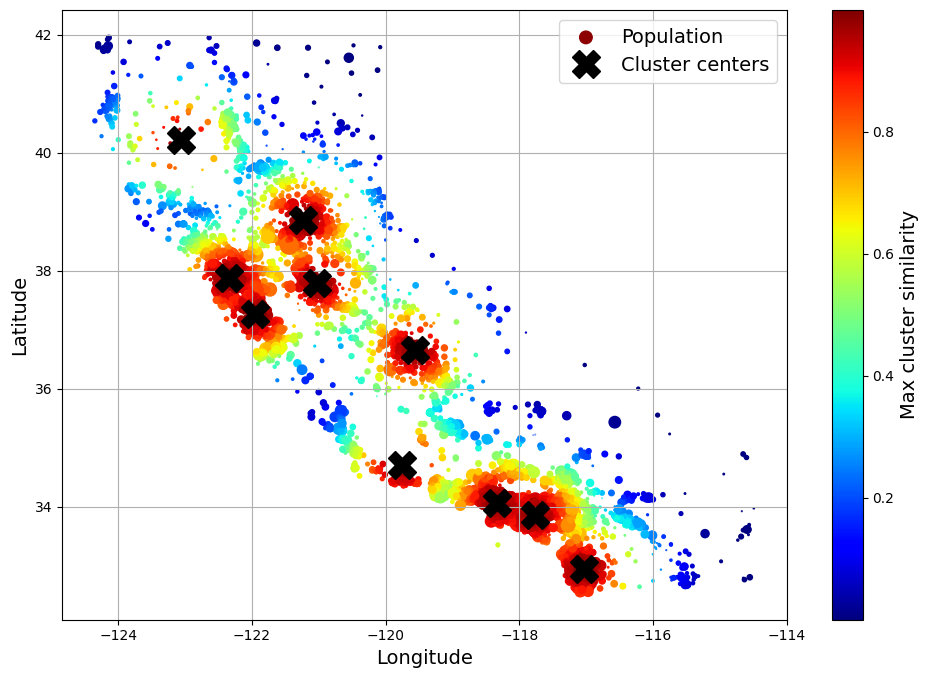

In [93]:
housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

housing_renamed.plot(kind="scatter", x="Longitude", y="Latitude", grid=True,
                     s=housing_renamed["Population"] / 100, label="Population",
                     c="Max cluster similarity",
                     cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10, 7))
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")
plt.legend(loc="upper right")
save_fig("district_cluster_plot")
plt.show()

## 변환 파이프라인

변환 단계는 올바른 순서로 실행되어야 함.
사이킷런은 변환순서대로 처리하도록 도와주는 Pipeline클래스를 제공함. 

수치 특성에서 누락되 값을 대체하고 스케일을 조정하느 간단한 파이프라인

In [94]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler())
])

변환기 이름이 짓는게 귀찮다면 make_pipeline()함수를 사용할 수 있음..

In [95]:
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

In [96]:
from sklearn import set_config

set_config(display='diagram')

num_pipeline

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [97]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

이를 데이터프레임으로 재구성하려면 파이프라인의 get_feature_names_out() 메서드 사용

In [98]:
df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared, columns=num_pipeline.get_feature_names_out(),
    index=housing_num.index)

In [99]:
df_housing_num_prepared.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942


In [100]:
num_pipeline.steps

[('simpleimputer', SimpleImputer(strategy='median')),
 ('standardscaler', StandardScaler())]

In [101]:
num_pipeline[1]

StandardScaler()

In [102]:
num_pipeline[:-1]

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median'))])

In [103]:
num_pipeline.named_steps["simpleimputer"]

SimpleImputer(strategy='median')

In [104]:
num_pipeline.set_params(simpleimputer__strategy="median")

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

지금까지 범주형 열과 수치형 열을 모두 다뤘음. 하나의 변환기로 각 열마다 적절한 변환을 적용하여 모든 열을 처리할 수 있으면 더 편할거 같음. -> `ColumnTransformer`

다음 코드는 이전에 만든 num_pipeline을 수치형 특성에, cat_pipeline을 범주형 턱성에 적용

In [105]:
from sklearn.compose import ColumnTransformer

num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

수치형이나 범주형처럼 주어진 타입의 모든 특성을 자도응로 선택해주는 : `make_column_selector` 클래스 사용,

변환기 이름에 짓는것이 귀찮다면 : `make_pipeline`처럼 `make_column_transformer()` 함수 사용

In [106]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

In [107]:
housing_prepared = preprocessing.fit_transform(housing)

필요하다면 데이터프레임으로 만들 수 있음

In [108]:
housing_prepared_fr = pd.DataFrame(
    housing_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=housing.index)
housing_prepared_fr.head(2)

,pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491,0.0,0.0,0.0,1.0,0.0
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942,1.0,0.0,0.0,0.0,0.0


### **이제 지금까지 실험한 모든 변환을 수행할 단일 파이프라인으로 작성**

파이프라인이 할 일, 그 이유:

 - 대부분 머신러닝 알고리즘은 누락된 값을 기대하지 않기 때문에 수치형 특성의 경우 누락도니 값을 중간값으로 대체함.
범주형 특성일 경우 누락된 값을 가장 많이 등장한 카테고리로 변경

- 대부분의 머신러닝 알고리즘은 수치 입력만 받기 때문에 범주형 특성을 원-핫 인코딩함.

- 비율 특성인 bedrooms_ratio, rooms_per_house, people_per_ouse를 계산하여 추가함. 이런 특성은 중간 주택 가격과 상관관계가 높으므로 머신러닝 모델에 도움이 되기를 기대해볼수 있음

- 몇 가지 클러스터 유사도 특성을 추가함. 위도 경도보다 모델에 더 유용할 가능성이 높음

- 대부분의 모델은 균등 분포나 가우스 분포에 가까운 특성을 선호하기 때문에 꼬리가 두꺼운 분포를 띠는 특승을 로그값으로 바꿔야함

- 대부분 머신러닝 알고리즘은 모든 특성이 대체로 동일한 스케일을 가질 때 작동하므로 모든 수치 특성을 표준화함

이 모든 작업을 수행하는 파이프라인 코드는 아래와 같음.

In [109]:
# 두 열을 받아 첫 번째 열 / 두 번째 열 비율을 계산하는 함수
# 예: total_bedrooms / total_rooms, total_rooms / households
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

# FunctionTransformer가 출력 특성 이름을 만들 때 사용할 이름 지정 함수
# 이 변환기는 항상 비율 하나만 만들기 때문에 이름을 "ratio"로 고정
def ratio_name(function_transformer, feature_names_in):
    return ["ratio"] # get_feature_names_out()에 사용

# 비율 특성을 만들기 위한 전용 파이프라인
def ratio_pipeline():
    return make_pipeline(
        # 결측값을 각 열의 중앙값으로 채움
        SimpleImputer(strategy="median"),

        # 위에서 만든 column_ratio 함수를 적용해 두 열의 비율 특성 생성
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),

        # 생성된 비율 값을 표준화
        StandardScaler()
    )

# 로그 변환을 적용할 숫자 특성용 파이프라인
log_pipeline = make_pipeline(
    # 결측값을 중앙값으로 채움
    SimpleImputer(strategy="median"),

    # np.log를 적용해 치우친 분포를 완화
    # feature_names_out="one-to-one"은 입력 특성 이름을 그대로 출력 이름으로 사용
    FunctionTransformer(np.log, feature_names_out="one-to-one"),

    # 로그 변환된 값을 표준화
    StandardScaler()
)

# 위도, 경도를 이용해 지역 클러스터와의 유사도 특성을 만드는 변환기
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

# 따로 지정되지 않은 나머지 숫자 특성에 적용할 기본 파이프라인
default_num_pipeline = make_pipeline(
    # 결측값을 중앙값으로 채움
    SimpleImputer(strategy="median"),

    # 숫자 특성을 표준화
    StandardScaler()
)

# 열마다 서로 다른 전처리 방식을 적용하는 ColumnTransformer
preprocessing = ColumnTransformer([
        # total_bedrooms / total_rooms 비율 생성
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),

        # total_rooms / households 비율 생성
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),

        # population / households 비율 생성
        ("people_per_house", ratio_pipeline(), ["population", "households"]),

        # 지정한 숫자 특성들에 로그 변환 + 표준화 적용
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),

        # latitude, longitude로 지리적 클러스터 유사도 특성 생성
        ("geo", cluster_simil, ["latitude", "longitude"]),

        # object 타입 범주형 특성에 cat_pipeline 적용
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],

    # 위에서 직접 지정하지 않은 나머지 특성에는 기본 숫자 파이프라인 적용
    # 여기서는 housing_median_age가 해당됨
    remainder=default_num_pipeline)

ColumnTransformer를 실행하면 모든 변환이 수해오디거 24개 특성을 가진 넘파이 배열이 출력됨.

In [110]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 24)

In [111]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__클러스터 0 유사도', 'geo__클러스터 1 유사도',
       'geo__클러스터 2 유사도', 'geo__클러스터 3 유사도', 'geo__클러스터 4 유사도',
       'geo__클러스터 5 유사도', 'geo__클러스터 6 유사도', 'geo__클러스터 7 유사도',
       'geo__클러스터 8 유사도', 'geo__클러스터 9 유사도',
       'cat__ocean_proximity_<1H OCEAN', 'cat__ocean_proximity_INLAND',
       'cat__ocean_proximity_ISLAND', 'cat__ocean_proximity_NEAR BAY',
       'cat__ocean_proximity_NEAR OCEAN', 'remainder__housing_median_age'],
      dtype=object)

# 모델 선택과 훈련

## 훈련 세트에서 후련하고 평가하기


간단한 선형 회귀 모델 훈련

In [112]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x000...
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000019B4172B350>)])),
                ('linearregression', LinearRegression())])

훈련 세트에서 적용하고 처음 다섯 개 예측과 레이블을 비교

In [113]:
housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(-2)  # -2 = 십의 자리에서 반올림

array([242800., 375900., 127500.,  99400., 324600.])

In [114]:
housing_labels.iloc[:5].values


array([458300., 483800., 101700.,  96100., 361800.])

RMSE 계산

In [115]:
from sklearn.metrics import mean_squared_error

lin_rmse = mean_squared_error(housing_labels, housing_predictions,
                              squared=False)
lin_rmse

68647.95686706669

없는 것보단 낫지만 확실히 좋은 점수는 아님.

대부분의 중간 주택 가격은 $120,000 ~ $265,000 사이임. 그러므로 예측 오차가 $68,628 인것은 만족스럽지 않음.

=> 과대적합 사례(트겅들이 좋은 예측을 만들만ㄷ큼 충분한 정보를 제공핮 못했거나 모델이 충분히 강력하지 못했다는 사라.)

이전에 공부했듯이 과대적합의 해결법은 더 강력한 모델을 사용하거나 훈련 알고리즘에 더 좋은 특성 추가, 모델의 규제 감소 등이 있음.

DecisionTreeRegressor 훈련 진행

In [116]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x000...
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000019B4172B350>)])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

모델 훈련후 훈련 세트로 평가

In [117]:
housing_predictions = tree_reg.predict(housing)
tree_rmse = mean_squared_error(housing_labels, housing_predictions,
                              squared=False)
tree_rmse

0.0

오차가 0이 나옴. 아주 심한 과대적합이 의심됨. 

이를 검증해야함.

## 교차 검증을 사용한 평가

데이터를 8:2로 나누고 훈련 세트를 더 작으 훈련세트와 검증 세트로 나눈 다음, 더 작은 모델을 훈련시키고 검증 세트로 모델을 평가하는 방법 대신,

**k-폴드 교차 검증(k-fold cross-validation)** 기능을 사용할 수도 있음.

아래의 코드는 훈련세트를 **폴드(fold)** 라는 중복되지 않은 10개의 서브셋으로 랜덤으로 분할하여 결정 토리 모델을 10번 훈련하고 평가함.

매번 다른 폴드를 선택해 평가에 사용. 그리고 9개 폴드는 훈련에 사용됩니다. 10개의 평가 점수가 담긴 배열이 결과가 됩니다.

In [118]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, housing, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)

In [119]:
pd.Series(tree_rmses).describe()

count       10.000000
mean     67153.318273
std       1963.580924
min      63925.253106
25%      66083.277180
50%      66795.829871
75%      68074.018403
max      70664.635833
dtype: float64

성능을 추정하는 것뿐만 아니라 이 추정이 얼마나 정확한지(표준 편차)측정할 수 있음.

수치 분석 : 
- 결정 트리 결과가 좋지 않음.
- 이 결정 트리는 평균 RMSE가 약 67,153이고 표준 편차가 약 1,963임.
- 선형 회귀 모델과 비교했을때 심한 과대적합 때문에 차이가 미미함.
- 훈련 오차가 작고(실제로 0) 검증 오차는 높기 때문에 과대적합임.

검증 세트를 하나만 사용했다면 이런 정보를 얻지 못했을 것임.

하지만 모델을 여러 번훈련시켜야 해서 비용이 비싸므로 항상 교차 검증을 쓸 수 있는 것은 아님.

마지막으로 RandomForestRegressor 모델 시도.

램덤 포레스트는 특성을 랜덤으로 선택해서 많은 결정 트리를 만들고 예측의 평균을 구하는 방식으로 작동됨.

서로 다른 모델들로 구성된 이런 모델을 **앙상블(ensemble)** 이라고 하는데, 앙상블은 기반 모델(여기서는 결정 트리)의 성능을 높임

In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg, housing, housing_labels,
                                scoring="neg_root_mean_squared_error", cv=10)

In [ ]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     47002.931706
std       1048.451340
min      45667.064036
25%      46494.358345
50%      47093.173938
75%      47274.873814
max      49354.705514
dtype: float64

랜덤 포레스트가 이 작업에 아주 잘 맞아보림.

여전히 과대적합인거 같음. 

여러 종류이 머신러닝 알고리즘에서 다양한 모델 (다양하 ㄴ커널의 서포트 벡터 머신, 신경망 등)을 시도해야함

# 모델 미세 튜닝

## 그리드 서치

가장 간단한 방법은 만족할 만한 하이퍼파라미터 조합을찾을 떄 까지 수동으로 하이퍼파라미터를 조정하는 것.

대신 `GridSearchCV`를 사용. 탐색하고자 하는 하이퍼파라미터와 시도해볼 값을 지정만 하면됨.

그러면 교차 검증을 사용해 가능한 모든 하이퍼파라미터 조합을 평가함. 아래의 코드는 `RandomForestRegressor`에 대한 최적 하이퍼파라미터 조합 찾는 코드

In [ ]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])
param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10],
     'random_forest__max_features': [4, 6, 8]},
    {'preprocessing__geo__n_clusters': [10, 15],
     'random_forest__max_features': [6, 8, 10]},
]
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(housing, housing_labels)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<f...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x000001F0FF8F4E10>)])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'preprocessing__geo__n_clusters': [5, 8, 10],
                          'random_forest__max_features': [4, 6, 8]},
                         {'preprocessing__geo__n_clusters': [10, 15],
                          'random_forest__max_features': [6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

`full_pipeline.get_params().keys()`를 사용해 전체 하이퍼파라미터 리스트를 얻을 수 있습니다:

In [ ]:
print(str(full_pipeline.get_params().keys())[:1000] + "...")

dict_keys(['memory', 'steps', 'verbose', 'preprocessing', 'random_forest', 'preprocessing__n_jobs', 'preprocessing__remainder__memory', 'preprocessing__remainder__steps', 'preprocessing__remainder__verbose', 'preprocessing__remainder__simpleimputer', 'preprocessing__remainder__standardscaler', 'preprocessing__remainder__simpleimputer__add_indicator', 'preprocessing__remainder__simpleimputer__copy', 'preprocessing__remainder__simpleimputer__fill_value', 'preprocessing__remainder__simpleimputer__keep_empty_features', 'preprocessing__remainder__simpleimputer__missing_values', 'preprocessing__remainder__simpleimputer__strategy', 'preprocessing__remainder__standardscaler__copy', 'preprocessing__remainder__standardscaler__with_mean', 'preprocessing__remainder__standardscaler__with_std', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 'preprocessing__transformers', 'preprocessing__verbose', 'preprocessing__verbose_feature_names_out', 'prepr

최상의 하이퍼파라미터 조합은 다음과 같음

In [ ]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [ ]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x000001F...
                                                  ClusterSimilarity(n_clusters=15,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000001F0FF96A9D0>)])),
                ('random_forest',
                 RandomForestRegressor(max_features=6, random_state=42))])

그리드 탐색에서 테스트한 하이퍼파라미터 조합의 점수를 확인할 수 있음:

In [ ]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
12,15,6,43536,43753,44569,43953
13,15,8,44084,44205,44863,44384
14,15,10,44368,44496,45200,44688
7,10,6,44251,44628,45857,44912
9,10,6,44251,44628,45857,44912


## 랜덤 서치

적은 수의 조합을 탐구할때는 그리드 서치가 좋지만, 가끔은 `RandomizedSearchCV`가 선호됨.

`GrideSearchCV`와 비슷하지만 모든 조합을 시도하는 대신 반복마다 하이퍼파라미터에 임의의 수를 대입하여 지정한 횟수만큼 평가함

램덤 서치 장점:
- 하이퍼파라미터 값이 연속적이면 랜덤서치를 1000번 실행했을때 각 하이퍼파라미터마다 1000개의 다른 값을 탐색함,

- 어떤 하이퍼파라미터가 성능 며에서 큰 차이를 만들지 못하지만 아직 이 사실을 모른다고 가정했을 했을때 -> 0개의 가능한 값이 있을 때 이를 그리드 서치에 추가하면 훈련이 10배 더 오래 걸립니다. 하지만 하이퍼파라미터를 랜덤 서치에 추가하면탐색 시간이 더 늘어나지 않음.

- 6개의 하이퍼파라미터에 대해 각 10개의 값ㅇ르 탐색한다면 그리드 서치는 백만 범 모델을 훈련해야 함. 반면 랜덤 서치는 지정한 반복 횟무만큼 실행할 수 있음 

In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

30개 (`n_iter` * `cv`)의 랜덤한 하이퍼파라미터 조합을 시도함:

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {'preprocessing__geo__n_clusters': randint(low=3, high=50),
                  'random_forest__max_features': randint(low=2, high=20)}

rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=42)

rnd_search.fit(housing, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001F0FFAB2090>,
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001F0FFC47190>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [ ]:
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)
cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
1,45,9,41115,42151,42695,41987
8,32,7,41604,42200,43219,42341
0,41,16,42106,42743,43443,42764
5,42,4,41812,42925,43557,42765
2,23,8,42421,43094,43856,43124


**보너스 섹션: 하이퍼파라미터를 위한 샘플링 분포 선택 방법**

* `scipy.stats.randint(a, b+1)`: a~b 사이의 _이산적인_ 값을 가진 하이퍼파라미터. 이 범위의 모든 값은 동일한 확률 가집니다.
* `scipy.stats.uniform(a, b)`: 매우 비슷하지만 _연속적인_ 파라미터에 사용합니다.
* `scipy.stats.geom(1 / scale)`: 이산적인 값의 경우 주어진 스케일 안에서 샘플링하고 싶을 때 사용합니다. 예를 들어 scale=1000인 경우 대부분의 샘플은 이 범주 안에 있지만 모든 샘플 중 10% 정도는 100보다 작고, 10% 정도는 2300보다 큽니다.
* `scipy.stats.expon(scale)`: `geom`의 연속적인 버전입니다. `scale`을 가장 많이 등장할 값으로 지정합니다.
* `scipy.stats.loguniform(a, b)`: 하이퍼파라미터 값의 스케일을 어떻게 지정할지 모를 때 사용합니다. a=0.01, b=100으로 지정하면 0.01과 0.1 사이의 샘플링과 10과 100 사이의 샘플링 비율이 동일합니다.

다음은 `randint()`, `uniform()`, `geom()`, `expon()`에 대한 확률 질량 함수(이산형 변수)와 확률 밀도 함수(연속형 변수)의 그래프입니다:

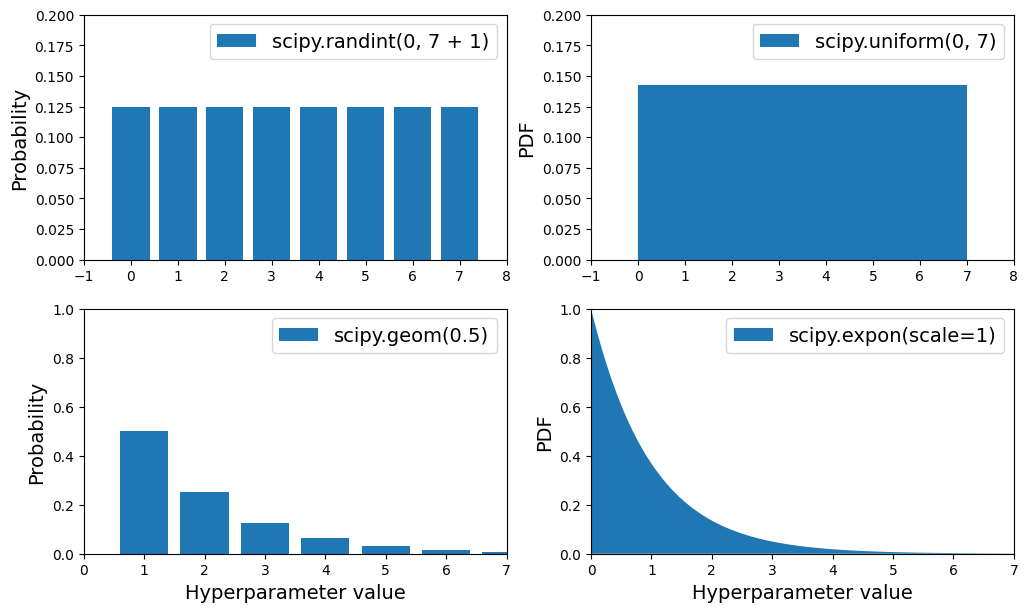

In [ ]:
# 추가 코드 – 랜덤 서치에서 사용할 수 있는 몇가지 분포에 대한 그래프

from scipy.stats import randint, uniform, geom, expon

xs1 = np.arange(0, 7 + 1)
randint_distrib = randint(0, 7 + 1).pmf(xs1)

xs2 = np.linspace(0, 7, 500)
uniform_distrib = uniform(0, 7).pdf(xs2)

xs3 = np.arange(0, 7 + 1)
geom_distrib = geom(0.5).pmf(xs3)

xs4 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.bar(xs1, randint_distrib, label="scipy.randint(0, 7 + 1)")
plt.ylabel("Probability")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 2)
plt.fill_between(xs2, uniform_distrib, label="scipy.uniform(0, 7)")
plt.ylabel("PDF")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 3)
plt.bar(xs3, geom_distrib, label="scipy.geom(0.5)")
plt.xlabel("Hyperparameter value")
plt.ylabel("Probability")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 4)
plt.fill_between(xs4, expon_distrib, label="scipy.expon(scale=1)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.show()

다음은 `expon()`와 `loguniform()`의 확률 밀도 함수(왼쪽 열), log(X)의 확률 밀도 함수(오른쪽 열). 

오른쪽 열은 하이퍼파라미터 스케일의 분포를 보여줌. `expon()`는 대체적으로 원하는 스케일을 따라 하이퍼파라미터를 선택하고 작은 스케일 쪽으로는 긴 꼬리를 형성함. 하지만 `loguniform()`는 스케일에 영향을 받지 않고 모두 동일한 확률을 가짐:

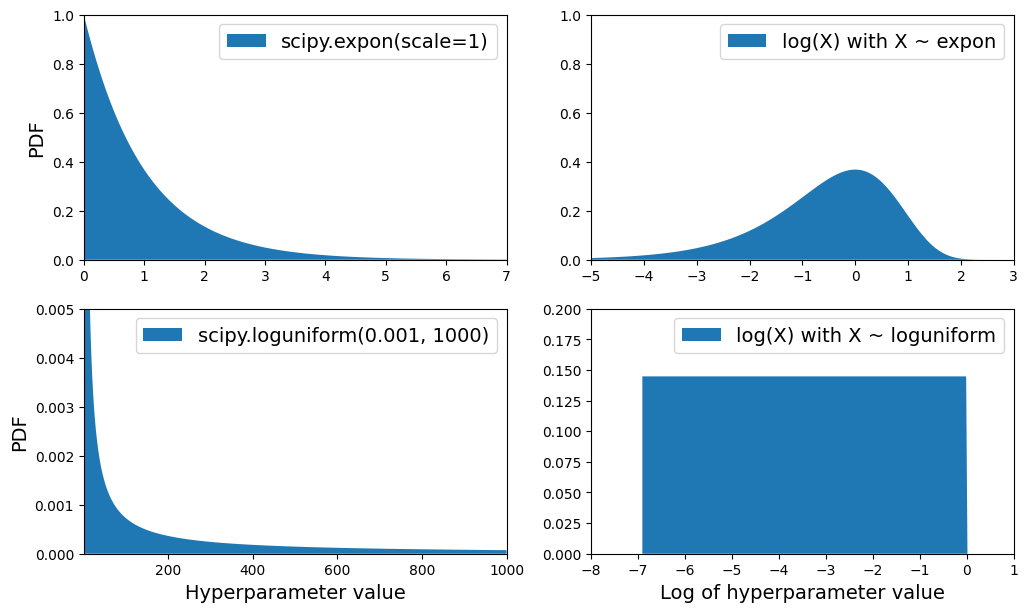

In [ ]:
# 추가 코드 – expon와 loguniform의 차이를 보여줌

from scipy.stats import loguniform

xs1 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs1)

log_xs2 = np.linspace(-5, 3, 500)
log_expon_distrib = np.exp(log_xs2 - np.exp(log_xs2))

xs3 = np.linspace(0.001, 1000, 500)
loguniform_distrib = loguniform(0.001, 1000).pdf(xs3)

log_xs4 = np.linspace(np.log(0.001), np.log(1000), 500)
log_loguniform_distrib = uniform(np.log(0.001), np.log(1000)).pdf(log_xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.fill_between(xs1, expon_distrib,
                 label="scipy.expon(scale=1)")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 2)
plt.fill_between(log_xs2, log_expon_distrib,
                 label="log(X) with X ~ expon")
plt.legend()
plt.axis([-5, 3, 0, 1])

plt.subplot(2, 2, 3)
plt.fill_between(xs3, loguniform_distrib,
                 label="scipy.loguniform(0.001, 1000)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0.001, 1000, 0, 0.005])

plt.subplot(2, 2, 4)
plt.fill_between(log_xs4, log_loguniform_distrib,
                 label="log(X) with X ~ loguniform")
plt.xlabel("Log of hyperparameter value")
plt.legend()
plt.axis([-8, 1, 0, 0.2])

plt.show()

## 최상의 모델과 오차 분석

In [ ]:
final_model = rnd_search.best_estimator_  # 전처리 포함됨
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.06, 0.06, 0.05, 0.01, 0.01, 0.01, 0.01, 0.19, 0.01, 0.01, 0.02,
       0.04, 0.01, 0.  , 0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.  ,
       0.01, 0.  , 0.01, 0.02, 0.02, 0.01, 0.01, 0.01, 0.03, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.  , 0.01, 0.01, 0.02, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.08,
       0.  , 0.  , 0.  , 0.01])

In [ ]:
sorted(zip(feature_importances,
           final_model["preprocessing"].get_feature_names_out()),
           reverse=True)

[(0.1898423270105783, 'log__median_income'),
 (0.07709175866873944, 'cat__ocean_proximity_INLAND'),
 (0.06455488601956336, 'bedrooms__ratio'),
 (0.056936146643377976, 'rooms_per_house__ratio'),
 (0.0490294770805355, 'people_per_house__ratio'),
 (0.038070690744923225, 'geo__클러스터 3 유사도'),
 (0.025643913400094476, 'geo__클러스터 22 유사도'),
 (0.021791275432437234, 'geo__클러스터 17 유사도'),
 (0.021575251507503695, 'geo__클러스터 6 유사도'),
 (0.017868654556924362, 'geo__클러스터 2 유사도'),
 (0.017431400050755975, 'geo__클러스터 32 유사도'),
 (0.015981159400591683, 'geo__클러스터 18 유사도'),
 (0.014888464257396877, 'geo__클러스터 40 유사도'),
 (0.014488389218107146, 'geo__클러스터 43 유사도'),
 (0.014252940099964142, 'geo__클러스터 7 유사도'),
 (0.014038173319370725, 'geo__클러스터 21 유사도'),
 (0.013846025114732157, 'geo__클러스터 38 유사도'),
 (0.01362570996472274, 'geo__클러스터 34 유사도'),
 (0.013547297167034428, 'geo__클러스터 41 유사도'),
 (0.012900089026066918, 'geo__클러스터 24 유사도'),
 (0.012620908145579916, 'geo__클러스터 10 유사도'),
 (0.011621275372313349, 'remainder__housi

위의 정보를 통해 덜 중요한 특성들을 제외할 수 있듬 (ex : ocean_proximity 카테고리 중 하나만 실제로 유용하므로 다른 카테고리를 제외 가능)

시스템이 특정한 오차를 만들었다면 왜 그런 문제가 생겼는지 이해해야 함. 그리고 추가 특성을 포함시키거나, 불필요한 특성을 제거하거나, 이상치를 제외하는 등 핵결 방법을 찾아야 함.


## 테스트 세트로 시스템 평가하기

어느정도 모델을 튜닝하면 만족할만한 결과가 나옴. 테스트 세트에서 최종 모델 평가 진행

In [ ]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(X_test)

final_rmse = mean_squared_error(y_test, final_predictions, squared=False)
print(final_rmse)

NameError: name 'strat_test_set' is not defined

테스트 RMSE에 대한 95% 신뢰 구간을 계산:

In [ ]:
from scipy import stats

confidence= 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) -1 ,
                         loc=squared_errors.mean(),
                         scale=stats.sem(squared_errors)))

수동 계산 버전:

In [ ]:
# RMSE에 대한 신뢰 구간 계산 방법
m = len(squared_errors)
mean = squared_errors.mean()
tscore = stats.t.ppf((1 + confidence) / 2, df=m - 1)
tmargin = tscore * squared_errors.std(ddof=1) / np.sqrt(m)
np.sqrt(mean - tmargin), np.sqrt(mean + tmargin)

또한, t-점수 대신 z-점수를 사용할 수도 있음. 테스트 세트가 너무 작지 않기 때문에 큰 차이가 없음. : 

In [ ]:
# -점수를 사용해 신뢰 구간 계산하기
zscore = stats.norm.ppf((1 + confidence) / 2)
zmargin = zscore * squared_errors.std(ddof=1) / np.sqrt(m)
np.sqrt(mean - zmargin), np.sqrt(mean + zmargin)